<a href="https://colab.research.google.com/github/minhtam3010050-jpg/TH_DEEP/blob/main/BT_TUAN4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2.1. Nạp thư viện

In [1]:
from keras.datasets import mnist
import numpy as np
import keras
from keras import layers

2.2. Nạp dataset

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784)
(10000, 784)


2.3. Xây dựng mô hình Autoencoder

In [4]:
encoding_dim = 32

input_img = keras.Input(shape=(784,))
encoded = layers.Dense(encoding_dim, activation='relu')(input_img)
decoded = layers.Dense(784, activation='sigmoid')(encoded)

autoencoder = keras.Model(input_img, decoded)

encoder = keras.Model(input_img, encoded)
encoded_input = keras.Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

2.4. Huấn luyện mô hình

In [7]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0102 - loss: 0.2750 - val_accuracy: 0.0105 - val_loss: 0.1895
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0114 - loss: 0.1721 - val_accuracy: 0.0126 - val_loss: 0.1553
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.0101 - loss: 0.1456 - val_accuracy: 0.0106 - val_loss: 0.1344
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0100 - loss: 0.1284 - val_accuracy: 0.0102 - val_loss: 0.1209
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0108 - loss: 0.1177 - val_accuracy: 0.0099 - val_loss: 0.1124
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.0116 - loss: 0.1106 - val_accuracy: 0.0107 - val_loss: 0.1065
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0114 - loss: 0.1056 - val_accuracy: 0.0125 - val_loss: 0.1023
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0116 - loss: 0.1019 - val_accu

2.5. Dự báo loại ảnh sử dụng Autoencoder

In [5]:
encoded_ims = encoder.predict(x_test)
decoded_ims = decoder.predict(encoded_ims)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


2.6. Hiển thị ảnh từ mô hình Autoencoder

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


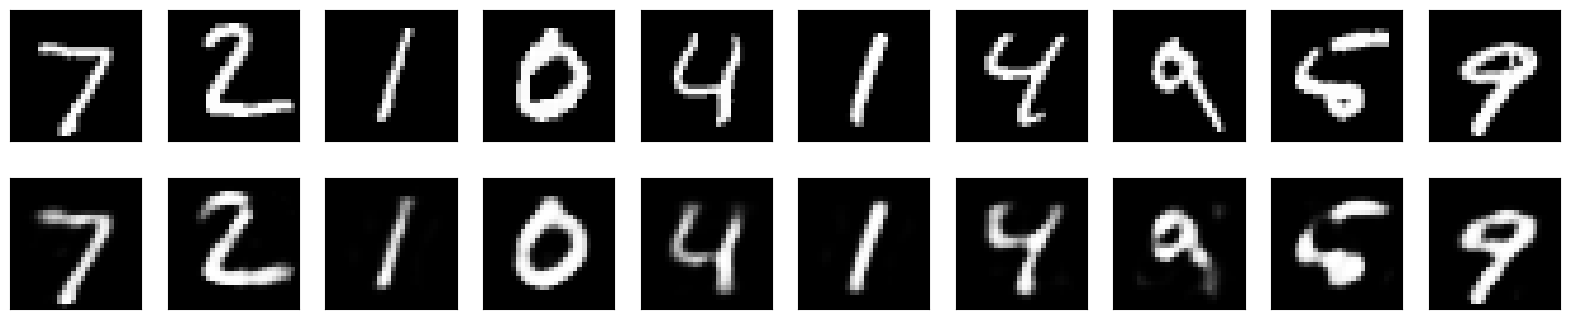

In [10]:
import matplotlib.pyplot as plt

decoded_ims = autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_ims[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

3.1. Thêm L1

In [12]:
from tensorflow.keras import regularizers
encoding_dim = 32
input_img = keras.Input(shape=(784,))
encoded = layers.Dense(encoding_dim, activity_regularizer=regularizers.l1(10e-5), activation='relu')(input_img)
decoded = layers.Dense(784, activation='sigmoid')(encoded)

autoencoder = keras.Model(input_img, decoded)

encoder = keras.Model(input_img, encoded)
encoded_input = keras.Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

In [13]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

autoencoder.fit(x_train, x_train,
                epochs=100,
                batch_size=256, verbose=1,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0143 - loss: 0.6554 - val_accuracy: 0.0161 - val_loss: 0.6155
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0150 - loss: 0.5832 - val_accuracy: 0.0161 - val_loss: 0.5535
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.0150 - loss: 0.5275 - val_accuracy: 0.0161 - val_loss: 0.5038
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0150 - loss: 0.4827 - val_accuracy: 0.0161 - val_loss: 0.4638
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0150 - loss: 0.4466 - val_accuracy: 0.0161 - val_loss: 0.4314
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0150 - loss: 0.4174 - val_accuracy: 0.0161 - val_loss: 0.4050
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.0146 - loss: 0.3935 - val_accuracy: 0.0161 - val_loss: 0.3834
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0150 - loss: 0.3739 - 

3.2. Thêm layers

In [15]:
encoding_dim = 32
input_img = keras.Input(shape=(784,))
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)
decoded = layers.Dense(784, activation='sigmoid')(encoded)

autoencoder = keras.Model(input_img, decoded)

encoder = keras.Model(input_img, encoded)
encoded_input = keras.Input(shape=(32,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

BAI TAP

Viết chương trình cài đặt Autoencoder để nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong
tensorflow với các nhãn sau

In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import numpy as np

(x_train, _), (x_test, _) = datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

input_img = layers.Input(shape=(32, 32, 3))
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 133s 335ms/step - loss: 0.5837 - val_loss: 0.5682
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 131s 336ms/step - loss: 0.5649 - val_loss: 0.5662
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 142s 336ms/step - loss: 0.5625 - val_loss: 0.5624
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 127s 324ms/step - loss: 0.5613 - val_loss: 0.5617
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 146s 335ms/step - loss: 0.5605 - val_loss: 0.5610
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 129s 329ms/step - loss: 0.5598 - val_loss: 0.5603
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 127s 325ms/step - loss: 0.5594 - val_loss: 0.5601
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 128s 328ms/step - loss: 0.5589 - val_loss: 0.5595
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 135s 344ms/step - loss: 0.5586 - val_loss: 0.5591
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 147s 356ms/step - loss: 0.5584 - val_loss: 0.5589


**RNN**

2.1. Nạp thư viện

In [19]:
from pandas import read_csv
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math
import matplotlib.pyplot as plt

2.2. Tạo hàm định nghĩa mô hình RNN

In [20]:

def create_RNN(hidden_units, dense_units, input_shape, activation):
    model = Sequential()
    model.add(SimpleRNN(hidden_units, input_shape=input_shape, activation=activation[0]))
    model.add(Dense(dense_units, activation=activation[1]))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

demo_RNN = create_RNN(2, 1, (3, 1), ['linear', 'linear'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2.3. Xem các tham số sinh bởi RNN

In [21]:
wx = demo_RNN.get_weights()[0]
wh = demo_RNN.get_weights()[1]
bh = demo_RNN.get_weights()[2]
wy = demo_RNN.get_weights()[3]
by = demo_RNN.get_weights()[4]

print('wx=', wx)
print('wh=', wh)
print('bh=', bh)
print('wy=', wy)
print('by=', by)

wx= [[0.78269184 1.1578985 ]]
wh= [[-0.46107662 -0.88736033]
 [ 0.88736033 -0.46107662]]
bh= [0. 0.]
wy= [[ 0.6077751]
 [-1.2743902]]
by= [0.]


2.4. Tính vector hidden cho tầng recurrent

In [22]:
x = np.array([1, 2, 3])
x_input = np.reshape(x, (1, 3, 1))
y_predict_model = demo_RNN.predict(x_input)

m = 2
h0 = np.zeros(m)
h1 = np.dot(x[0], wx) + bh + h0
h2 = np.dot(x[1], wx) + np.dot(h1, wh) + bh
h3 = np.dot(x[2], wx) + np.dot(h2, wh) + bh

o3 = np.dot(h3, wy) + by

print('h1:', h1)
print('h2:', h2)
print('h3:', h3)

print('Prediction of model:', y_predict_model)
print('Prediction from computation:', o3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
h1: [[0.78269184 1.15789855]]
h2: [[2.23197601 1.08738746]]
h3: [[2.28386806 0.99175973]]
Prediction of model: [[0.12418902]]
Prediction from computation: [[0.12418922]]


3.1. Đọc dữ liệu

In [26]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
# XÓA HOẶC COMMENT DÒNG DƯỚI ĐÂY:
# from keras import engine

def get_train_test(url, split_percent=0.8):
    df = pd.read_csv(url, usecols=[1], engine='python')
    data = np.array(df.values.astype('float32'))
    scaler = MinMaxScaler(feature_range=(0, 1))
    data = scaler.fit_transform(data).flatten()

    n = len(data)

    split = int(n * split_percent)
    train_data = data[range(split)]
    test_data = data[split:]
    return train_data, test_data, data

sunspots_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv'
train_data, test_data, data = get_train_test(sunspots_url)

3.2. Chuẩn bị dữ liệ

In [27]:
def get_XY(dat, time_steps):
    #indices target arrays
    y_ind = np.arange(time_steps, len(dat), time_steps)
    Y = dat[y_ind]

    #prepare X
    row_x = len(Y)
    X = dat[range(time_steps * row_x)]
    X = np.reshape(X, (row_x, time_steps, 1))
    return X, Y

time_steps = 12
trainX, trainY = get_XY(train_data, time_steps)
testX, testY = get_XY(test_data, time_steps)

3.3. Tạo RNN model và huấn luyện

In [28]:
model = create_RNN(hidden_units=3, dense_units=1, input_shape=(time_steps,1), activation=['tanh','tanh'])
model_fit = model.fit(trainX, trainY, epochs=20, verbose =1)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2975
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2524 
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2142 
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1809 
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1532 
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1298 
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1123 
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0984
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0870 
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0790 
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0723 
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0666 
Epoch 13/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0622 
Epoch 14/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0584 
Epoch 15/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0548 
Epoch 16/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/st

3.4. Hàm tính hiệu quả model

In [29]:
def print_error(trainY, testY, train_predict, test_predict):
    train_rmse = math.sqrt(mean_squared_error(trainY, train_predict))
    test_rmse = math.sqrt(mean_squared_error(testY, test_predict))
    print('Train RMSE: %.3f RMSE' % (train_rmse))
    print('Test RMSE: %.3f RMSE' % (test_rmse))

train_predict = model.predict(trainX)
test_predict = model.predict(testX)

print_error(trainY, testY, train_predict, test_predict)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Train RMSE: 0.200 RMSE
Test RMSE: 0.336 RMSE


3.5. Đánh giá kết quả

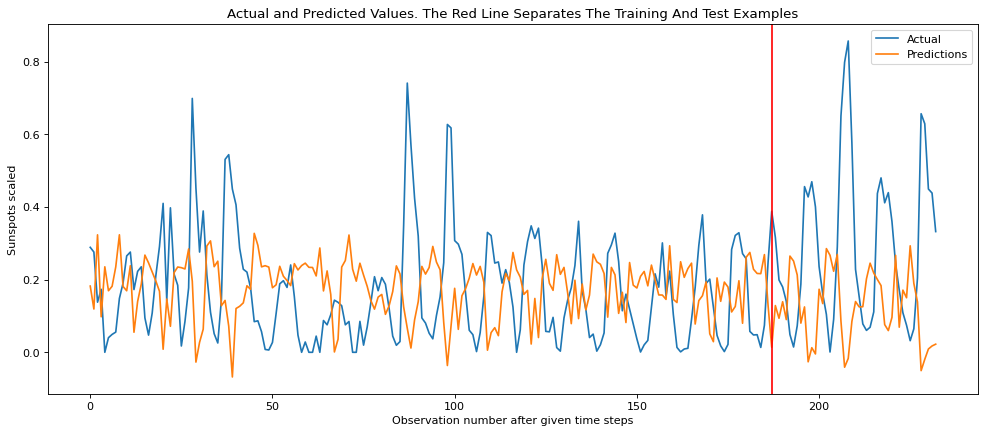

In [30]:
def plot_result(trainY, testY, train_predict, test_predict):
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)
    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual)
    plt.plot(range(rows), predictions)
    plt.axvline(x=len(trainY), color='r')
    plt.legend(['Actual', 'Predictions'])
    plt.xlabel('Observation number after given time steps')
    plt.ylabel('Sunspots scaled')
    plt.title('Actual and Predicted Values. The Red Line Separates The Training And Test Examples')
    plt.show()

plot_result(trainY, testY, train_predict, test_predict)